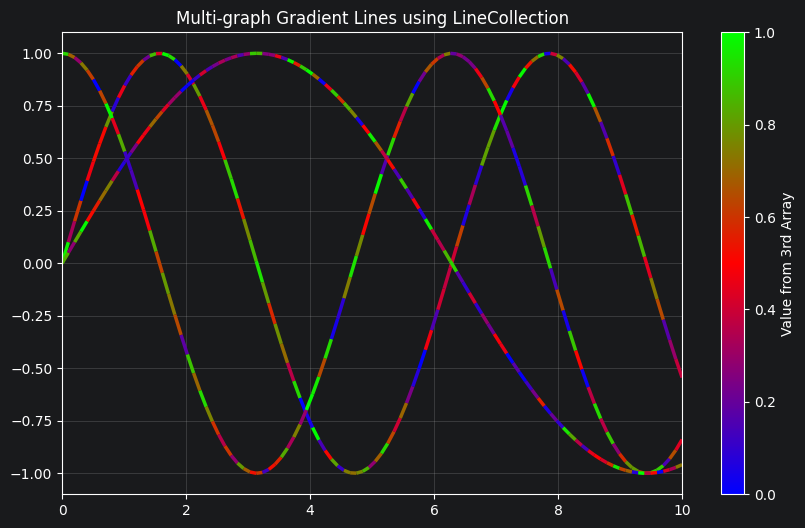

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# 1. Setup Data
x = np.linspace(0, 10, 100)
# y is (100, 3) -> 100 points per line, 3 different lines
y = np.array([np.sin(x), np.cos(x), np.sin(x / 2)]).T
# color_values is (100, 3) -> determines color at each segment
color_values = np.linspace(0, 1, 100).reshape(-1, 1) * np.ones((1, 3))
color_values = np.random.rand(100, 3)

fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('brg')
norm = plt.Normalize(vmin=0, vmax=1)

# 2. Loop through each column (graph)
for i in range(y.shape[1]):
    # Create segments: (x0, y0) to (x1, y1)
    points = np.array([x, y[:, i]]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Create LineCollection
    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2.5)

    # Set the array to use for the color mapping
    lc.set_array(color_values[:, i])

    # Add to plot
    line = ax.add_collection(lc)

# 3. Finalize Plot
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min() - 0.1, y.max() + 0.1)

# Add colorbar using the last LineCollection object
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label('Value from 3rd Array')

ax.set_title('Multi-graph Gradient Lines using LineCollection')
plt.grid(True, alpha=0.3)
plt.show()